# Velocity Profile Visualization

Reads the CSV produced by `utils::saveProfileToCSV` and plots the cornering, acceleration, braking, and final combined profiles.

Set `CSV_PATH` below to the file your controller writes out.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "velocity_profile.csv"  # <-- change to your actual file path

df = pd.read_csv(CSV_PATH)
df.head()

,Index,Velocity_Profile,Velocity_Accel,Velocity_Brake,Velocity_Corner
0,0,20.0069,20.0069,24.6652,32.16
1,1,20.5601,20.5601,23.7863,32.16
2,2,21.1555,21.1555,22.6978,32.16
3,3,21.6080,21.7330,21.6080,32.16
4,4,20.4588,22.2533,20.4588,32.16


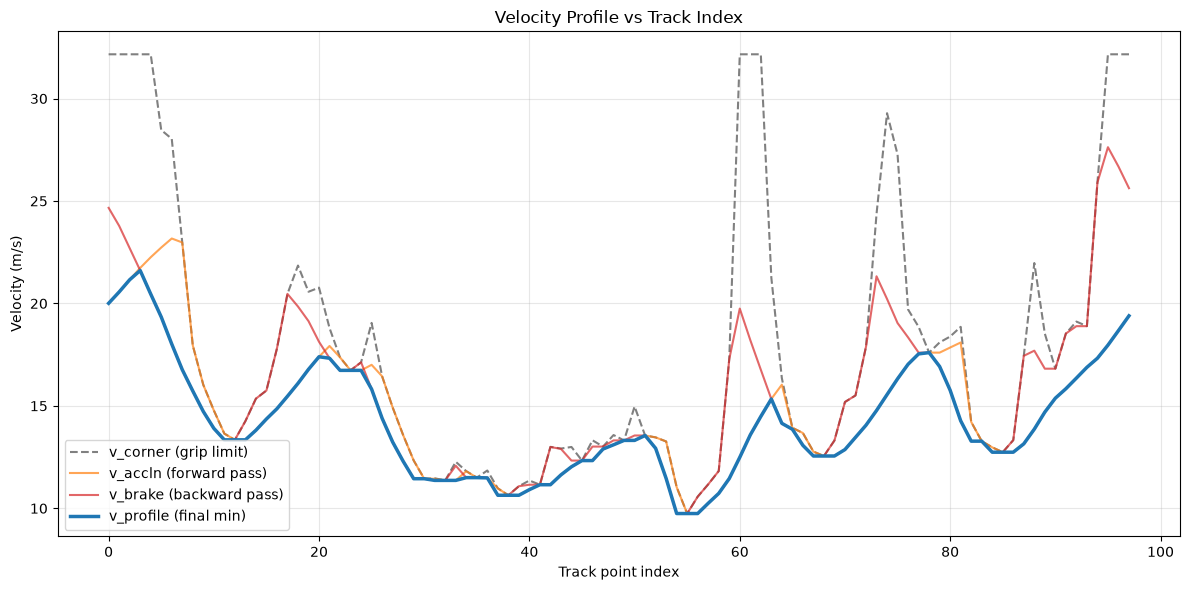

In [2]:
# Line plot: all four channels vs track index
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df["Index"], df["Velocity_Corner"], label="v_corner (grip limit)", linestyle="--", color="gray")
ax.plot(df["Index"], df["Velocity_Accel"], label="v_accln (forward pass)", color="tab:orange", alpha=0.7)
ax.plot(df["Index"], df["Velocity_Brake"], label="v_brake (backward pass)", color="tab:red", alpha=0.7)
ax.plot(df["Index"], df["Velocity_Profile"], label="v_profile (final min)", color="tab:blue", linewidth=2.5)

ax.set_xlabel("Track point index")
ax.set_ylabel("Velocity (m/s)")
ax.set_title("Velocity Profile vs Track Index")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sanity checks

- `v_profile` should never exceed `v_corner` at any index (it's a hard grip ceiling).
- `v_profile` should be smooth and continuous across the seam (`Index` = 0 and `Index` = last) if the closed-loop wrap fix is working correctly.
- Sharp spikes in `v_accln` or `v_brake` that get clipped down by `v_corner` are expected right before/after corners — that's the forward/backward passes doing their job.

In [3]:
violations = df[df["Velocity_Profile"] > df["Velocity_Corner"] + 1e-6]
print(f"Points where v_profile exceeds v_corner: {len(violations)}")
violations

Points where v_profile exceeds v_corner: 0


,Index,Velocity_Profile,Velocity_Accel,Velocity_Brake,Velocity_Corner


In [4]:
# Check continuity at the wrap seam (index 0 vs last index)
first_row = df.iloc[0]
last_row = df.iloc[-1]

print("First point profile speed:", first_row["Velocity_Profile"])
print("Last point profile speed: ", last_row["Velocity_Profile"])
print("Seam speed jump:", abs(first_row["Velocity_Profile"] - last_row["Velocity_Profile"]))

First point profile speed: 20.0069
Last point profile speed:  19.3954
Seam speed jump: 0.611500000000003


## Optional: track-shaped speed heatmap

If you extend `saveProfileToCSV` to also write out the point `x`, `y` coordinates (e.g. add `X,Y` columns), this cell will plot the track shape colored by target speed — much easier to spot which corners are speed-limiting than an index plot.

In [ ]:
if "X" in df.columns and "Y" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    sc = ax.scatter(df["X"], df["Y"], c=df["Velocity_Profile"], cmap="viridis", s=40)
    ax.plot(df["X"], df["Y"], color="black", alpha=0.15, linewidth=1)
    ax.set_aspect("equal")
    ax.set_title("Track shape colored by target speed")
    plt.colorbar(sc, label="Velocity (m/s)")
    plt.show()
else:
    print("No X,Y columns found — add point coordinates to the CSV to enable this plot.")